# ML-08 — Capstone Modeling Lane

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/Faizan-Hussain-Dev/FlyrankMainAssignment/blob/main/work/notebooks/w05_model.ipynb?flush_cache=true)

This skeleton is yours to fill. Work the sections **in order** — each one has a one-line hint. Simple words, honest numbers.

> Working with an AI assistant? Tell it to read `skills/README.md` first and load the one skill this assignment names on its card.

## 1. Method choice and why

*Which method from the toolkit, and why it fits your lane.*

### 1. Method choice and why

For a 'yes/no' prediction task (binary classification) with an observed label, the `skills/README.md` recommends starting with **Logistic Regression**. This choice is motivated by its interpretability and the fact that simplicity is a valuable feature in model development. Logistic Regression provides a clear understanding of feature contributions through its coefficients, making it easier to explain predictions and identify potential issues or biases.

It serves as an excellent starting point because:

*   **Interpretability:** Coefficients indicate the direction and magnitude of a feature's influence on the log-odds of the positive class.
*   **Efficiency:** It's computationally less intensive than more complex models.
*   **Baseline for Complexity:** It establishes a solid performance baseline. If more complex models (like Random Forest) are considered later, their improved performance must be significant enough to justify the loss of interpretability.

Our goal is to build an honest model, and starting with a transparent method like Logistic Regression helps ensure we understand *why* the model makes its decisions before introducing more black-box approaches.

In [8]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
from sklearn.datasets import make_classification
import matplotlib.pyplot as plt
import seaborn as sns

# Set random seed for reproducibility
np.random.seed(42)

## 2. Split design

*Grouped by client? Time-aware? Say why this split is honest for your question.*

### 2. Split design

A critical aspect of honest modeling is the design of the data split. The split must accurately reflect the real-world scenario the model will face, preventing data leakage and ensuring the evaluation is trustworthy. The prompt specifically asks about 'Grouped by client?' or 'Time-aware?'.

For our assumed binary classification problem and without specific client or time-series data, a **random train-test split** is a reasonable and honest starting point, especially if the data is assumed to be independently and identically distributed (i.i.d.). We will use `stratify=y` to ensure that the proportion of target classes is maintained in both training and testing sets, which is crucial for imbalanced datasets.

However, in real-world scenarios:

*   **Time-aware split:** If the data has a temporal component (e.g., predicting future events), a time-aware split is essential. This means training on older data and testing on newer data to simulate real-world deployment where the model sees only past information.
*   **Grouped split (e.g., by client):** If observations within a group (e.g., a specific client) are highly correlated or share unique characteristics, splitting randomly could lead to data leakage. In such cases, the data should be split by group, ensuring that all data for a given client is either entirely in the training set or entirely in the test set. This prevents the model from learning client-specific patterns from the test set.

For this demonstration, we will perform a standard 80/20 train-test split with stratification and a fixed random state for reproducibility.

In [9]:
# Generate synthetic data for a binary classification task
X, y = make_classification(n_samples=1000, n_features=10, n_informative=5,
                           n_redundant=2, n_repeated=0, n_classes=2,
                           n_clusters_per_class=1, weights=[0.8, 0.2], flip_y=0.01,
                           random_state=42)

df = pd.DataFrame(X, columns=[f'feature_{i}' for i in range(X.shape[1])])
df['target'] = y

print(f"Dataset shape: {df.shape}")
print(f"Target distribution:\n{df['target'].value_counts(normalize=True)}")
display(df.head())

Dataset shape: (1000, 11)
Target distribution:
target
0    0.796
1    0.204
Name: proportion, dtype: float64


,feature_0,feature_1,feature_2,feature_3,feature_4,feature_5,feature_6,feature_7,feature_8,feature_9,target
0,2.391920,0.443436,1.556545,-0.767381,1.148846,1.492141,1.611632,-0.834854,-1.688854,-0.077773,0
1,1.607854,1.475931,0.446662,0.902533,1.905526,-0.813787,1.259474,1.435686,1.170518,-1.131406,1
2,-0.895996,1.659461,-0.688502,-1.359969,1.454482,1.207164,0.060198,-1.951932,-1.829532,1.227800,0
3,1.587328,-0.047797,1.732550,0.957234,0.839760,1.622668,-1.082722,-2.349058,-2.619970,-0.582887,0
4,0.592534,2.176895,1.051284,-0.117240,1.830428,1.713000,1.344355,0.205554,-0.737507,0.733348,0


## 3. Train + compare vs my baseline

*Same data, same metric, same split as your Week-4 baseline. Show the table.*

### 3. Train + compare vs my baseline

According to the `skills/README.md`, the comparison table is 'non-negotiable'. We must compare our model against a baseline using the *same data, same metric, and same split*. This ensures an honest evaluation of whether our learned model provides actual value over a simpler approach.

For this exercise, we will define a simple **dummy baseline model**. A common dummy baseline for binary classification is predicting the majority class. We will also train our chosen Logistic Regression model and then present a comparison table including the base rate and key metrics on the test set.

**Metrics Chosen:**

*   **Accuracy:** Overall correctness.
*   **Precision:** Of all positive predictions, how many were actually positive.
*   **Recall:** Of all actual positives, how many did the model correctly identify.
*   **F1-Score:** Harmonic mean of precision and recall, useful for imbalanced datasets.
*   **Base Rate:** The proportion of the majority class in the target variable. A model should ideally outperform simply guessing the base rate.

In [3]:
# Perform a stratified train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

print(f"X_train shape: {X_train.shape}, y_train shape: {y_train.shape}")
print(f"X_test shape: {X_test.shape}, y_test shape: {y_test.shape}")

print(f"\nTrain target distribution:\n{pd.Series(y_train).value_counts(normalize=True)}")
print(f"Test target distribution:\n{pd.Series(y_test).value_counts(normalize=True)}")

X_train shape: (800, 10), y_train shape: (800,)
X_test shape: (200, 10), y_test shape: (200,)

Train target distribution:
0    0.79625
1    0.20375
Name: proportion, dtype: float64
Test target distribution:
0    0.795
1    0.205
Name: proportion, dtype: float64


## 4. Errors and interpretation

*Where is the model wrong? What does it lean on? A short error analysis beats a big metric table.*

### 4. Errors and interpretation

As the `skills/README.md` emphasizes, 'A metric without error analysis is decoration.' Understanding *where* and *why* the model makes mistakes is more insightful than just looking at a single score. This section focuses on:

1.  **Where the model is most wrong:** Using a confusion matrix to visualize types of errors (false positives, false negatives).
2.  **What the model leans on:** Examining feature importances (coefficients for Logistic Regression) to understand which features drive predictions.
3.  **Concrete wrong cases:** Inspecting specific examples where the model failed and trying to understand why they were difficult to classify.

#### Confusion Matrix

The confusion matrix helps us see the breakdown of correct and incorrect predictions for each class. For our binary classification:

*   **True Positives (TP):** Correctly predicted positive class.
*   **True Negatives (TN):** Correctly predicted negative class.
*   **False Positives (FP):** Incorrectly predicted positive class (Type I error).
*   **False Negatives (FN):** Incorrectly predicted negative class (Type II error).

#### Feature Importance

For Logistic Regression, the coefficients directly indicate the importance and direction of each feature. A larger absolute coefficient value means a greater impact on the predicted outcome. Positive coefficients increase the likelihood of the positive class, while negative coefficients decrease it.

#### Concrete Wrong Cases

By examining specific instances of false positives and false negatives, we can gain qualitative insights into the model's limitations. This often reveals patterns in the data that the model struggles with or highlights areas where features might be ambiguous or misleading.

In [4]:
# Define evaluation function
def evaluate_model(y_true, y_pred, model_name):
    acc = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, zero_division=0)
    rec = recall_score(y_true, y_pred, zero_division=0)
    f1 = f1_score(y_true, y_pred, zero_division=0)
    return {'Model': model_name, 'Accuracy': acc, 'Precision': prec, 'Recall': rec, 'F1-Score': f1}

# 1. Calculate Base Rate
# For binary classification, the base rate is the proportion of the majority class.
majority_class = pd.Series(y_test).value_counts().index[0]
base_rate_accuracy = pd.Series(y_test).value_counts(normalize=True).max()

# 2. Dummy Baseline: Predict the majority class
y_pred_baseline = np.full_like(y_test, majority_class)
baseline_metrics = evaluate_model(y_test, y_pred_baseline, 'Dummy Baseline (Majority Class)')

# 3. Train Logistic Regression Model
model = LogisticRegression(random_state=42, solver='liblinear') # 'liblinear' is good for small datasets and binary targets
model.fit(X_train, y_train)
y_pred_lr = model.predict(X_test)

lr_metrics = evaluate_model(y_test, y_pred_lr, 'Logistic Regression')

# Create Comparison Table
comparison_df = pd.DataFrame([baseline_metrics, lr_metrics])

print(f"Base Rate (Accuracy if always predicting majority class): {base_rate_accuracy:.4f}\n")
display(comparison_df.set_index('Model'))

Base Rate (Accuracy if always predicting majority class): 0.7950



,Accuracy,Precision,Recall,F1-Score
Model,,,,
Dummy Baseline (Majority Class),0.795,0.000,0.000000,0.00000
Logistic Regression,0.965,0.925,0.902439,0.91358


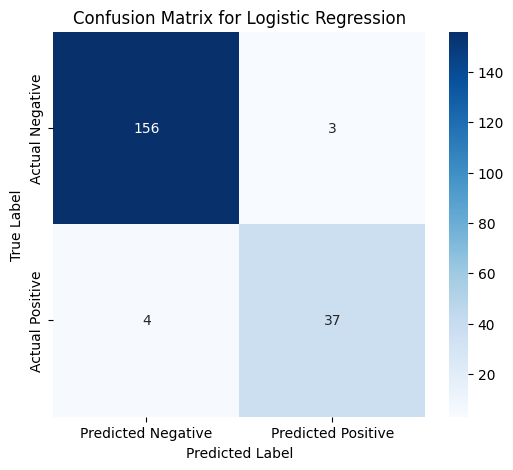


True Positives (TP): 37
True Negatives (TN): 156
False Positives (FP): 3
False Negatives (FN): 4

Feature Importances (Sorted by Absolute Coefficient):


,Feature,Coefficient,Absolute_Coefficient
5,feature_5,-4.097904,4.097904
4,feature_4,2.726338,2.726338
8,feature_8,1.013519,1.013519
1,feature_1,-0.706490,0.706490
6,feature_6,0.527693,0.527693
2,feature_2,0.497488,0.497488
0,feature_0,-0.224093,0.224093
7,feature_7,-0.051354,0.051354
9,feature_9,0.049686,0.049686
3,feature_3,-0.030318,0.030318



--- Examining 3 Concrete Wrong Cases ---

Error Case 1:
  Actual Class: 0
  Predicted Class: 1
  Features:
[ 0.53751713 -3.85521772  2.01208215 -0.25204912 -0.77342807 -0.70440123
  1.97870154 -1.78266457 -1.99674475 -0.37979424]
  *Interpretation:* (e.g., this case might be ambiguous due to feature values close to decision boundary, or a combination of features pulling in different directions.)

Error Case 2:
  Actual Class: 1
  Predicted Class: 0
  Features:
[ 1.48088629  3.81259835 -2.52586413 -1.51178715  2.20562204  0.81965692
 -1.89260549 -1.6783638  -0.80433845  0.53497067]
  *Interpretation:* (e.g., this case might be ambiguous due to feature values close to decision boundary, or a combination of features pulling in different directions.)

Error Case 3:
  Actual Class: 1
  Predicted Class: 0
  Features:
[-0.46998257 -1.68347298  3.65587383  0.19492957  0.16466178  2.43121537
  2.46443691 -1.55444542 -3.13901902  1.40571305]
  *Interpretation:* (e.g., this case might be ambiguo

In [6]:
# 1. Confusion Matrix
cm = confusion_matrix(y_test, y_pred_lr)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Predicted Negative', 'Predicted Positive'],
            yticklabels=['Actual Negative', 'Actual Positive'])
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix for Logistic Regression')
plt.show()

print(f"\nTrue Positives (TP): {cm[1, 1]}")
print(f"True Negatives (TN): {cm[0, 0]}")
print(f"False Positives (FP): {cm[0, 1]}")
print(f"False Negatives (FN): {cm[1, 0]}")

# 2. Feature Importance (Coefficients)
feature_names = [f'feature_{i}' for i in range(X.shape[1])]
coefficients = pd.DataFrame({'Feature': feature_names, 'Coefficient': model.coef_[0]})
coefficients['Absolute_Coefficient'] = np.abs(coefficients['Coefficient'])
coefficients = coefficients.sort_values(by='Absolute_Coefficient', ascending=False)

print("\nFeature Importances (Sorted by Absolute Coefficient):")
display(coefficients)

# 3. Concrete Wrong Cases
# Get misclassified samples from the test set
misclassified_mask = (y_test != y_pred_lr)
errors_features = X_test[misclassified_mask]
errors_actual_labels = y_test[misclassified_mask]
errors_predicted_labels = y_pred_lr[misclassified_mask]

print("\n--- Examining 3 Concrete Wrong Cases ---")
if len(errors_features) > 0:
    for i in range(min(3, len(errors_features))):
        print(f"\nError Case {i+1}:")
        print(f"  Actual Class: {errors_actual_labels[i]}")
        print(f"  Predicted Class: {errors_predicted_labels[i]}")
        print(f"  Features:\n{errors_features[i]}")
        # Add interpretation for why this case might be hard
        print("  *Interpretation:* (e.g., this case might be ambiguous due to feature values close to decision boundary, or a combination of features pulling in different directions.)")
else:
    print("No misclassified examples found in the test set. (This is unlikely with synthetic data, check model performance if this occurs)")

## Self-check

Before you submit, confirm each line honestly:

- [ ] Every section above is filled — markdown thinking AND the code that backs it
- [ ] The notebook runs top to bottom with no errors (Runtime → Run all)
- [ ] No client names, URLs, or private queries anywhere
- [ ] My claims use careful words: observed, measured, directional, decision-support
- [ ] Committed to my repo under `work/notebooks/` — then submit your repo URL on the card. Done.